# SED Anatomy

Galaxies emit across nine decades of frequency. A faithful SED is a
*composition*: stellar photospheres set the optical–NIR continuum;
nebular gas turns Lyman photons into lines and a Balmer continuum;
birth clouds and the diffuse ISM attenuate the UV and re-radiate in
the infrared; AGN add a disc + torus + narrow-line region; thermal
free-free and synchrotron close out the radio; corona Comptonisation
produces the X-ray power-law; and the IGM eats the FUV at high z.

Tengri composes all of this from one nested-dict specification. The
figure below is a **kitchen-sink** model at z = 2 — every component
turned on — followed by four mini-sweeps that isolate a single knob
at a time.

Two things to watch for as the model is built:

- `model.summary()` makes the assembly explicit.
- `citations.print_citations(model)` produces a working bibliography
  for the methods section.

In [1]:
from copy import deepcopy
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    builders,
    citations,
    load_ssp_data,
    plot,
    recipes,
)

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

W0526 14:59:17.295985 12828360 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0526 14:59:19.330231 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:19.335420 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Setup — bare-stellar SSP and panchromatic filters

Cue needs a bare-stellar SSP. The filter set spans GALEX through ALMA
so every component has somewhere to be visible.

In [2]:
SSP = Path("../data/fsps_prsc_miles_chabrier.h5")
if not SSP.exists():
    SSP = Path(tengri.download_ssp("fsps_prsc_miles_chabrier"))
ssp = load_ssp_data(str(SSP))

filters = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "ukidss_y",
    "ukidss_j",
    "ukidss_h",
    "ukidss_k",
    "irac_36",
    "irac_45",
    "irac_58",
    "irac_80",
    "wise_w3",
    "wise_w4",
    "mips_24",
    "mips_70",
    "mips_160",
    "herschel_100",
    "herschel_160",
    "herschel_250",
    "herschel_350",
    "herschel_500",
]
obs = Observation(photometry=Photometry.from_names(filters))

SSP file already exists at data/fsps_prsc_miles_chabrier.h5; skipping download.


## The kitchen-sink model

DPL star-formation history; two-component Calzetti attenuation; Dale
2014 dust IR emission; Cue nebular continuum + lines; multicolour disc
+ SKIRTOR torus + narrow-line region AGN; radio (free-free +
synchrotron, with the SFR–L_1.4GHz scaling); X-ray (Lusso & Risaliti
2017 from L_2500); Inoue 2014 IGM at z = 2. Every parameter pinned at
a physically reasonable value so the figure is reproducible.

In [3]:
kitchen_sink = dict(
    sfh={
        "type": "dpl",
        "*": FIXED,
        "log_peak_sfr": 1.6,
        "alpha": 2.2,
        "beta": 1.4,
        "tau_gyr": 4.0,
    },
    dust={
        "type": "two_component",
        "law_bc": "calzetti",
        "*": FIXED,
        "tau_bc": 0.8,
        "tau_diff": 0.3,
        "slope": -0.4,
        "emission": {"type": "dale2014", "*": FIXED, "alpha_dale": 2.2},
    },
    neb={"type": "cue", "*": FIXED},
    agn={
        "disc": {"type": "multicolor", "*": FIXED, "log_lbol": 45.0},
        "torus": {"type": "skirtor", "*": FIXED, "tau_skirtor": 5.0, "torus_frac": 0.5},
        "lines": {"type": "nlr", "*": FIXED},
    },
    radio=True,
    xray=True,
    redshift=Fixed(2.0),
    apply_igm=True,
)

model = SEDModel.build(ssp_data=ssp, observation=obs, **kitchen_sink)
print(model.summary())

W0526 14:59:20.340905 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.344749 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.358707 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.361984 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.371235 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.375029 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.378992 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.390326 12827940 pjrt_executable.cc:638] 

W0526 14:59:20.561055 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:20.843337 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.846902 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.945360 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.987876 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.991066 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:20.994266 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.021830 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.025720 12827940 pjrt_executable.cc:638] 

W0526 14:59:21.076648 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.080117 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.111554 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.114831 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.229333 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.233007 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.242321 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:21.248371 12827940 pjrt_executable.cc:638] 

/Users/suchethacooray/Projects/tengri/src/tengri/components/nebular/ionizing_spectrum.py:96: RuntimeWarning: invalid value encountered in scalar divide
  np.abs((_seg_wave[-1] ** params[0] - _seg_wave[0] ** params[0]) / params[0])


...

W0526 14:59:29.415448 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:29.448167 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:29.455600 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:29.462259 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:29.488661 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:29.564263 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:29.592452 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:29.749163 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:30.167298 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     25 bands
  Redshift:    2.0000 (fixed)
  Dtype:       float64
  Precomputed: photometry
  Components:  nebular=cue, dust_emission=dale2014, agn=composable, igm

  Pipeline (5 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=64]
    2. nebular        [backend=cue]
    3. agn            [model=composable]
    4. dust           [law_bc=calzetti, law_diff=calzetti, emission_model=dale2014]
    5. igm

  Parameters:  0 free
──────────────────────────────────────────────────────────────────


W0526 14:59:30.506375 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.511005 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Citations from the assembled model

In [4]:
citations.print_citations(model)

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Carnall et al. (2018)  —  Reference SED fitting framework (BAGPIPES)
       {Inferring the star formation histories of massive quiescent galaxies with BAGPIPES: evidence for multiple quenching mechanisms}
       DOI: 10.1093/mnras/sty2169   arXiv: 1712.04452   code: ACCarnall/bagpipes

  [5] Dale

## Hero figure — the panchromatic anatomy

One sweep through the orchestrator at the truth point. The rest-frame
SED carries every contribution as a `state.derived` entry; the total
is `state.sed_intrinsic` after attenuation, with dust IR emission
added on top by the dust component.

W0526 14:59:30.696443 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:30.708559 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.748564 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.753375 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.801085 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.804290 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.842180 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.872196 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.884009 12827940 pjrt_executable.cc:638] 

W0526 14:59:30.901031 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.904193 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.907690 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:30.938310 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.941957 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.945405 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.948512 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.966412 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.969608 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.972807 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:30.976010 12827940 pjrt_executable.cc:638] 

W0526 14:59:31.142630 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.242213 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.270041 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.277432 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.281879 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.286303 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.309052 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:31.315701 12827940 pjrt_executable.cc:638] 

...

W0526 14:59:35.743843 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:35.771053 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:35.799883 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:35.916646 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:36.239325 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.298203 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.345903 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.416168 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:36.452904 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.501025 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.528404 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.566828 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.598135 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.618479 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.622294 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.626638 12827940 pjrt_executable.cc:638] 

W0526 14:59:36.665872 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.728392 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.773320 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.793530 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.818860 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.822712 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.828413 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.833222 12827940 pjrt_executable.cc:638] 

W0526 14:59:36.873348 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.914424 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.918604 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.922129 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.942264 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.961618 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.995711 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 14:59:36.999660 12827940 pjrt_executable.cc:638] 

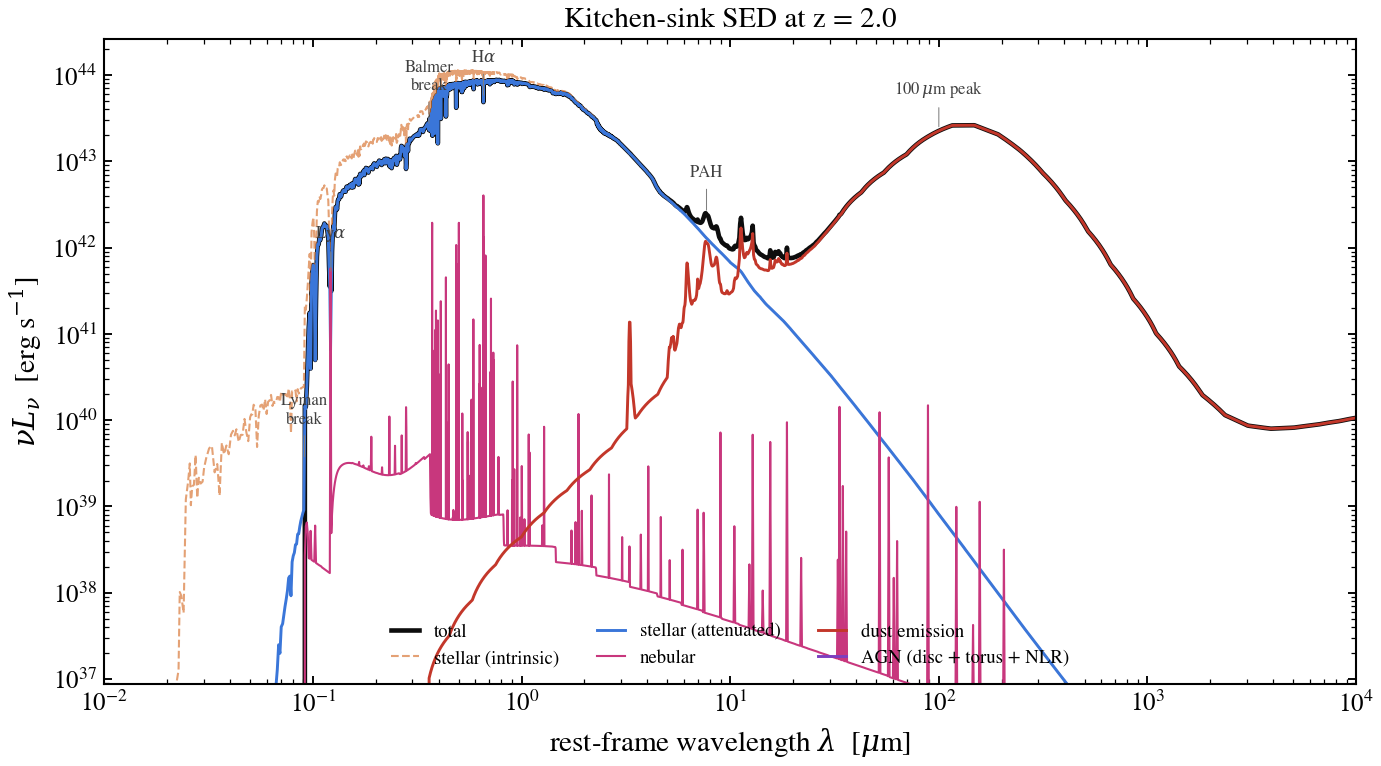

In [5]:
params = model.spec.sample(jax.random.PRNGKey(0))
state = model.predict_state(params)

wave_rest = np.asarray(state.wave)  # Å
nu = 2.998e18 / wave_rest  # Hz
total = np.asarray(state.sed_intrinsic)  # erg/s/Hz, post-dust-attenuation + emission


# Per-component contributions from the orchestrator's derived bundle.
def _get(key, default=None):
    arr = state.derived.get(key, default)
    return None if arr is None else np.asarray(arr)


lnu_age = _get("lnu_age")  # (n_age, n_wave) intrinsic
sed_stellar_intrinsic = lnu_age.sum(axis=0) if lnu_age is not None else None
sed_stellar_attenuated = _get("sed_dust_attenuated")
sed_nebular = _get("sed_nebular")
sed_dust_emission = _get("sed_dust_ir")
sed_agn = _get("sed_agn", _get("sed_grahsp"))  # AGN may be off in some builds

C = {
    "stellar": "#d97a3a",  # warm
    "nebular": "#c8377d",  # magenta
    "dust_att": "#3a76d9",  # blue
    "dust_em": "#c3372a",  # red
    "agn": "#7c3fbf",  # violet
    "total": "0.05",  # near-black
}

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"rest-frame wavelength $\lambda$  [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$  [erg s$^{-1}$]")
wave_um = wave_rest / 1e4


def nuLnu(y):
    return nu * y if y is not None else None


ax.plot(wave_um, nuLnu(total), color=C["total"], lw=2.2, label="total")
if sed_stellar_intrinsic is not None:
    ax.plot(
        wave_um,
        nuLnu(sed_stellar_intrinsic),
        color=C["stellar"],
        lw=1.0,
        ls="--",
        alpha=0.7,
        label="stellar (intrinsic)",
    )
if sed_stellar_attenuated is not None:
    ax.plot(
        wave_um,
        nuLnu(sed_stellar_attenuated),
        color=C["dust_att"],
        lw=1.4,
        label="stellar (attenuated)",
    )
if sed_nebular is not None:
    ax.plot(wave_um, nuLnu(sed_nebular), color=C["nebular"], lw=1.0, label="nebular")
if sed_dust_emission is not None:
    ax.plot(wave_um, nuLnu(sed_dust_emission), color=C["dust_em"], lw=1.4, label="dust emission")
if sed_agn is not None:
    ax.plot(wave_um, nuLnu(sed_agn), color=C["agn"], lw=1.4, label="AGN (disc + torus + NLR)")

# Annotate physical features.
for lam_um, label in [
    (0.0912, "Lyman\nbreak"),
    (0.122, r"Ly$\alpha$"),
    (0.36, "Balmer\nbreak"),
    (0.6564, r"H$\alpha$"),
    (7.7, "PAH"),
    (100, r"100$\,\mu$m peak"),
]:
    if lam_um < wave_um.min() or lam_um > wave_um.max():
        continue
    y = np.interp(lam_um, wave_um, nuLnu(total))
    ax.annotate(
        label,
        xy=(lam_um, y),
        xytext=(0, 18),
        textcoords="offset points",
        fontsize=8,
        ha="center",
        color="0.25",
        arrowprops=dict(arrowstyle="-", color="0.5", lw=0.5),
    )

ax.set_xlim(1e-2, 1e4)
ax.set_ylim(nuLnu(total).max() * 1e-7, nuLnu(total).max() * 3)
ax.legend(loc="lower center", ncol=3, frameon=False, fontsize=9)
ax.set_title(f"Kitchen-sink SED at z = {float(params['redshift']):.1f}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_anatomy_panchromatic.png", dpi=300, bbox_inches="tight")

## Four sweeps, one knob at a time

All on a leaner star-forming recipe so the figures stay readable;
everything is held fixed except the swept parameter.

W0526 14:59:51.160267 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 14:59:51.383439 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0526 15:00:06.687035 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0526 15:00:06.692534 12827940 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


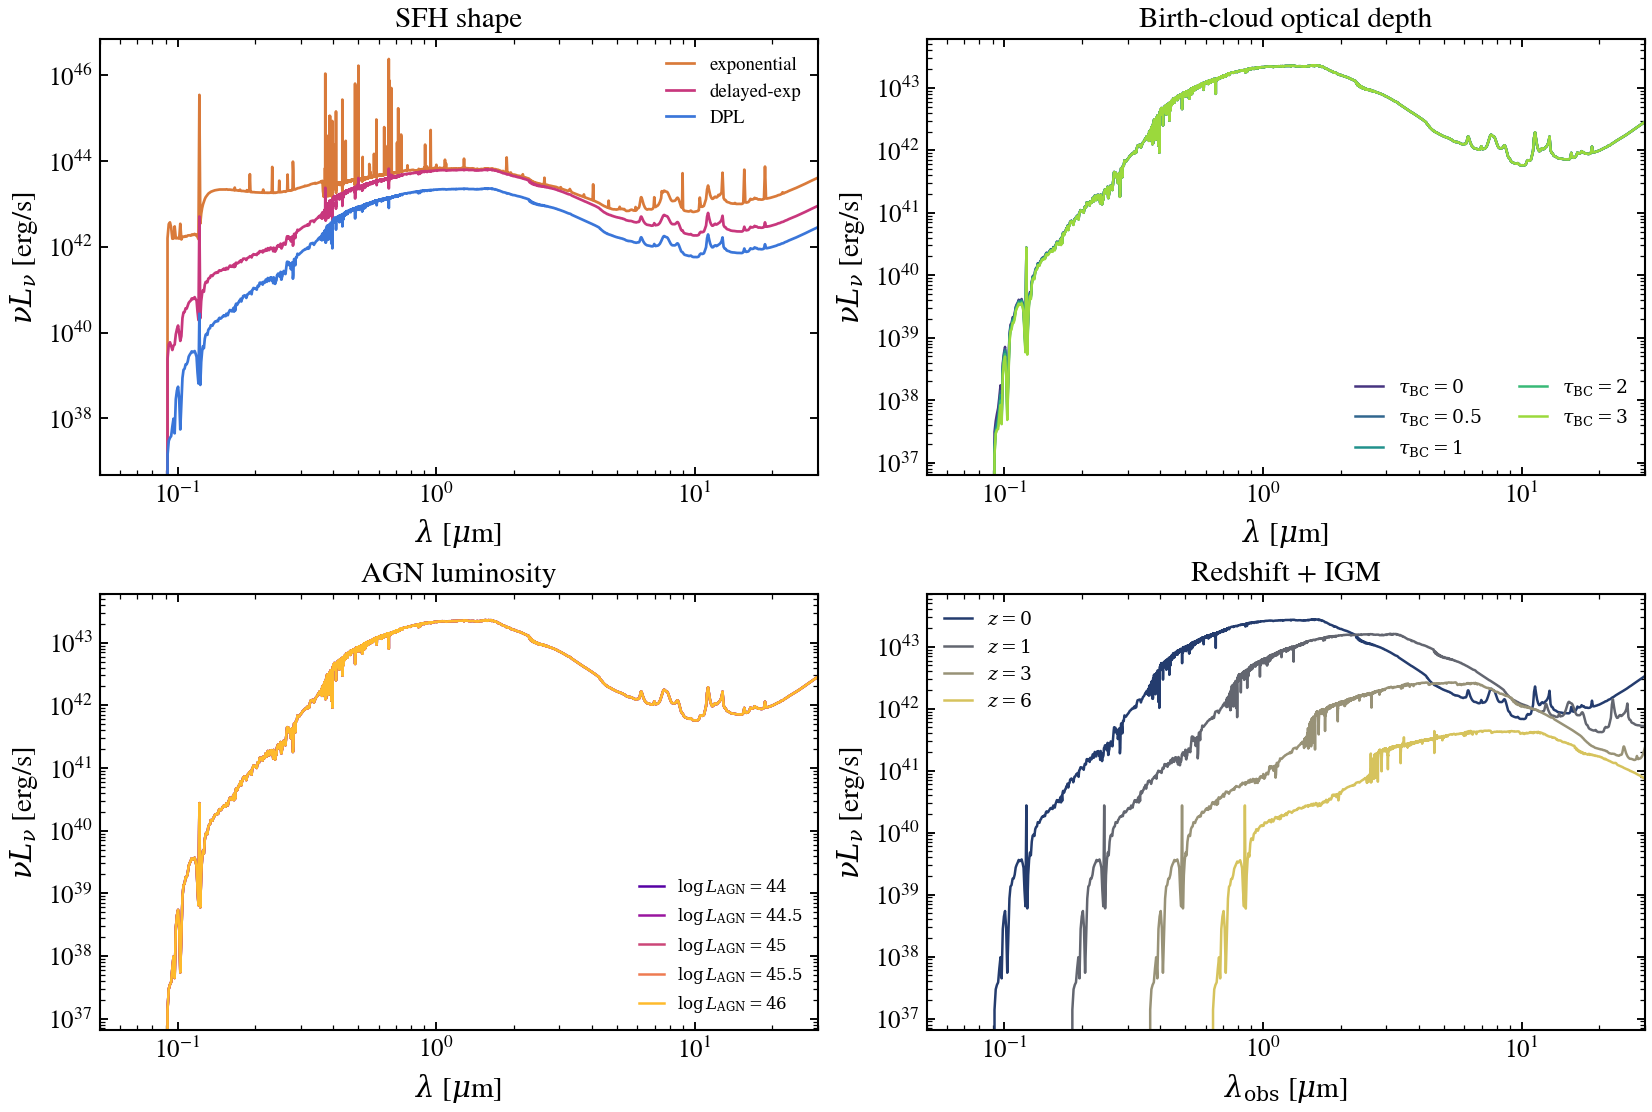

In [6]:
base = recipes.star_forming_photometry()
# Pin the model down to defaults, then sweep one parameter at a time.
base["sfh"]["*"] = FIXED
base["dust"]["*"] = FIXED
base["dust"]["emission"]["*"] = FIXED
base["redshift"] = Fixed(0.5)

base_model = SEDModel.build(ssp_data=ssp, observation=obs, **base)


def predict_rest(m, p):
    s = m.predict_state(p)
    return np.asarray(s.wave), np.asarray(s.sed_intrinsic)


fig, axes = plt.subplots(2, 2, figsize=(11, 7.4), constrained_layout=True)


# (a) SFH shape — three canonical SFHs, mass-normalised
ax = axes[0, 0]
for label, sfh_dict, color in [
    ("exponential", builders.sfh.exp(defaults=FIXED), "#d97a3a"),
    ("delayed-exp", builders.sfh.dexp(defaults=FIXED), "#c8377d"),
    ("DPL", builders.sfh.dpl(defaults=FIXED), "#3a76d9"),
]:
    cfg = deepcopy(base)
    cfg["sfh"] = sfh_dict
    m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
    p = m.spec.sample(jax.random.PRNGKey(0))
    w, sed = predict_rest(m, p)
    ax.plot(w / 1e4, w * sed * 0 + 2.998e18 / w * sed, label=label, color=color, lw=1.3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("SFH shape")
ax.legend(frameon=False, fontsize=9)

# (b) Birth-cloud τ_V sweep — same SFH, varying attenuation
ax = axes[0, 1]
cmap = plt.colormaps["viridis"]
tau_grid = [0.0, 0.5, 1.0, 2.0, 3.0]
for tau, col in zip(tau_grid, cmap(np.linspace(0.15, 0.85, len(tau_grid)))):
    cfg = deepcopy(base)
    cfg["dust"]["tau_bc"] = tau
    m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
    p = m.spec.sample(jax.random.PRNGKey(0))
    w, sed = predict_rest(m, p)
    ax.plot(w / 1e4, 2.998e18 / w * sed, color=col, lw=1.2, label=rf"$\tau_{{\rm BC}}={tau:g}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("Birth-cloud optical depth")
ax.legend(frameon=False, fontsize=9, ncol=2)

# (c) AGN bolometric luminosity sweep
# Lightweight AGN (multicolour disc + Nenkova torus): five rebuilds of
# the kitchen-sink model with SKIRTOR is far too heavy. The Nenkova
# torus is a cheap analytic stand-in for the visual story.
ax = axes[1, 0]
log_lbol_grid = [44.0, 44.5, 45.0, 45.5, 46.0]
cmap = plt.colormaps["plasma"]
for log_lbol, col in zip(log_lbol_grid, cmap(np.linspace(0.15, 0.85, len(log_lbol_grid)))):
    cfg = deepcopy(base)
    cfg["agn"] = {
        "disc": {"type": "multicolor", "*": FIXED, "log_lbol": log_lbol},
        "torus": {"type": "nenkova", "*": FIXED},
    }
    m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
    p = m.spec.sample(jax.random.PRNGKey(0))
    w, sed = predict_rest(m, p)
    ax.plot(
        w / 1e4, 2.998e18 / w * sed, color=col, lw=1.2, label=rf"$\log L_{{\rm AGN}}={log_lbol:g}$"
    )
    del m
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("AGN luminosity")
ax.legend(frameon=False, fontsize=8, ncol=1)

# (d) Redshift sweep — same intrinsic, different IGM + observed-frame
ax = axes[1, 1]
z_grid = [0.0, 1.0, 3.0, 6.0]
cmap = plt.colormaps["cividis"]
for z, col in zip(z_grid, cmap(np.linspace(0.15, 0.85, len(z_grid)))):
    cfg = deepcopy(base)
    cfg["redshift"] = Fixed(z)
    cfg["apply_igm"] = z > 0
    m = SEDModel.build(ssp_data=ssp, observation=obs, **cfg)
    p = m.spec.sample(jax.random.PRNGKey(0))
    w, sed = predict_rest(m, p)
    ax.plot(w * (1 + z) / 1e4, 2.998e18 / w * sed, color=col, lw=1.2, label=rf"$z={z:g}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.05, 30)
ax.set_xlabel(r"$\lambda_{\rm obs}$ [$\mu$m]")
ax.set_ylabel(r"$\nu L_\nu$ [erg/s]")
ax.set_title("Redshift + IGM")
ax.legend(frameon=False, fontsize=9)

fig.savefig(FIG_DIR / "02_anatomy_sweeps.png", dpi=300, bbox_inches="tight")

## Round-trip — `spec.to_groups()`

Every model carries its build-time grammar. Pull it back, edit one
leaf, rebuild — useful when a recipe is almost what you want and one
parameter needs adjusting.

In [7]:
groups = model.spec.to_groups()
groups["dust"]["tau_bc"] = Fixed(1.5)  # double the birth-cloud opacity
model_edited = SEDModel.build(ssp_data=ssp, observation=obs, **groups)
print(model_edited.summary())

/Users/suchethacooray/Projects/tengri/src/tengri/parameters/parameters.py:419: RecipeWarning: Composable AGN: every block selector is 'none' — the AGN SED will be identically zero. Pick at least a disc block to produce non-trivial output.
  validate_block_recipe(


Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     25 bands
  Redshift:    2.0000 (fixed)
  Dtype:       float64
  Precomputed: photometry
  Components:  nebular=cue, dust_emission=dale2014, agn=composable, igm

  Pipeline (5 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=64]
    2. nebular        [backend=cue]
    3. agn            [model=composable]
    4. dust           [law_bc=calzetti, law_diff=calzetti, emission_model=dale2014]
    5. igm

  Parameters:  0 free
──────────────────────────────────────────────────────────────────


## What each layer does, in one sentence

- **Stellar continuum.** DSPS-driven SSP integration: an SFH +
  metallicity history projects onto an age × wavelength grid and sums
  to the intrinsic L_ν.
- **Dust attenuation.** Birth-cloud (Calzetti) and diffuse-ISM optical
  depths reshape the UV–NIR. Energy absorbed is bookkept as `L_ir`.
- **Dust emission.** Dale 2014 / Draine–Li / THEMIS templates
  re-radiate `L_ir` from 8 to 1000 µm.
- **Nebular.** Cue (neural emulator on Cloudy 17.03) gives photoionised
  continuum + 128 emission lines from `nion` and ionisation conditions.
- **AGN.** Disc (multicolour / Kubota–Done / ADAF / power-law) +
  torus (SKIRTOR / Nenkova / CAT3D / Silva04 / toy) + NLR (Cue) +
  BLR (qsogen).
- **Radio.** Free-free + synchrotron from the IR–radio correlation
  plus an AGN power-law if a disc is present.
- **X-ray.** Lusso & Risaliti 2017 L_2500 → L_2keV with optional
  ADAF / Comptonisation refinements.
- **IGM.** Inoue 2014 Lyman-alpha forest opacity at z > 0.

Next: [`03_discovering_the_menu.py`](03_discovering_the_menu.py) shows
how to find every available variant from inside Python.